In [4]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
data = np.load("wesad_balanced_multiwindow.npz")
X, y = data["X"], data["y"]

In [6]:
print(X[0].shape, y[0].shape)  # (3, 3000, 1) (3, 3000)

(512, 11) ()


In [7]:
print(y[24])

1


In [8]:
print(np.unique(y, return_counts=True))  # label distribution

(array([0, 1]), array([37260, 37260]))


In [9]:
class WESADDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # [B, T, D]
        self.y = torch.tensor(y, dtype=torch.long)     # [B]
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
def split_dataset(X, y, test_size=0.2, val_size=0.25, random_state=42):
    """
    Splits dataset into train/val/test sets with stratification.
    """
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=random_state)

    summary = pd.DataFrame({
        'Split': ['Train', 'Validation', 'Test'],
        'Total': [len(y_train), len(y_val), len(y_test)],
        'Class 0': [np.sum(y_train == 0), np.sum(y_val == 0), np.sum(y_test == 0)],
        'Class 1': [np.sum(y_train == 1), np.sum(y_val == 1), np.sum(y_test == 1)],
    })

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), summary

In [11]:
(X_train, y_train), (X_val, y_val),(X_test,y_test),summary= split_dataset(X, y, test_size=0.2, val_size=0.25, random_state=42)

train_dataset = WESADDataset(X_train, y_train)
val_dataset = WESADDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [12]:
import torch
import torch.nn as nn

class ModalityBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)

    def forward(self, x):  # [B, T, input_dim]
        _, (hn, _) = self.lstm(x)
        return torch.cat((hn[0], hn[1]), dim=1)  # [B, 2*H]

In [13]:
class AttentionFusion(nn.Module):
    def __init__(self, embed_dim, num_modalities):
        super().__init__()
        self.attn_weights = nn.Parameter(torch.randn(num_modalities, embed_dim))

    def forward(self, embeddings):  # [B, M, D]
        scores = torch.einsum('bmd,md->bm', embeddings, self.attn_weights)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # [B, M, 1]
        return (embeddings * weights).sum(dim=1)


In [14]:
class MultimodalBiLSTM(nn.Module):
    def __init__(self, modality_dims, hidden_dim=64, num_classes=3):
        super().__init__()
        self.modalities = nn.ModuleDict({
            name: ModalityBiLSTM(input_dim=dim, hidden_dim=hidden_dim)
            for name, dim in modality_dims.items()
        })
        self.fusion = AttentionFusion(embed_dim=2 * hidden_dim, num_modalities=len(modality_dims))
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):  # x: [B, T, D]
        embeddings = []
        for name, module in self.modalities.items():
            idx = self._modality_indices[name]
            x_mod = x[:, :, idx]
            embeddings.append(module(x_mod))  # [B, 2*H]
        fused = self.fusion(torch.stack(embeddings, dim=1))  # [B, 2*H]
        return self.classifier(fused)

    @property
    def _modality_indices(self):
        return {
            'ACC': slice(0, 3),
            'EDA': slice(3, 4),
            'TEMP': slice(4, 5),
            'Resp': slice(5, 6),
            'BVP': slice(6, 11)
        }


In [15]:
modality_dims = {
    'ACC': 3, 'EDA': 1, 'TEMP': 1, 'Resp': 1, 'BVP': 5
}
model = MultimodalBiLSTM(modality_dims, hidden_dim=64, num_classes=2)


In [16]:
def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(dataloader.dataset), correct / len(dataloader.dataset)

In [17]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(dataloader.dataset), correct / len(dataloader.dataset)

In [18]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

In [19]:
for epoch in range(10):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

Epoch 01 | Train Loss: 0.2861 | Acc: 0.8954 | Val Loss: 0.2098 | Acc: 0.9268
Epoch 02 | Train Loss: 0.2075 | Acc: 0.9249 | Val Loss: 0.1943 | Acc: 0.9336
Epoch 03 | Train Loss: 0.1860 | Acc: 0.9346 | Val Loss: 0.1579 | Acc: 0.9462
Epoch 04 | Train Loss: 0.1739 | Acc: 0.9444 | Val Loss: 0.1730 | Acc: 0.9475
Epoch 05 | Train Loss: 0.1690 | Acc: 0.9474 | Val Loss: 0.1494 | Acc: 0.9534
Epoch 06 | Train Loss: 0.1747 | Acc: 0.9411 | Val Loss: 0.1707 | Acc: 0.9487
Epoch 07 | Train Loss: 0.1382 | Acc: 0.9569 | Val Loss: 0.1184 | Acc: 0.9639
Epoch 08 | Train Loss: 0.1537 | Acc: 0.9482 | Val Loss: 0.1499 | Acc: 0.9507
Epoch 09 | Train Loss: 0.1395 | Acc: 0.9513 | Val Loss: 0.1247 | Acc: 0.9565
Epoch 10 | Train Loss: 0.1433 | Acc: 0.9526 | Val Loss: 0.1978 | Acc: 0.9404


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [21]:
def evaluate_infer(model, loader, criterion, device, print_report=False):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()

            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    if print_report:
        print("\n📊 Classification Report:")
        print(classification_report(all_labels, all_preds, digits=4))

        print("\n🧮 Confusion Matrix:")
        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("Confusion Matrix")
        plt.show()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)



📊 Classification Report:
              precision    recall  f1-score   support

           0     0.9687    0.9101    0.9385      7452
           1     0.9152    0.9706    0.9421      7452

    accuracy                         0.9404     14904
   macro avg     0.9420    0.9404    0.9403     14904
weighted avg     0.9420    0.9404    0.9403     14904


🧮 Confusion Matrix:


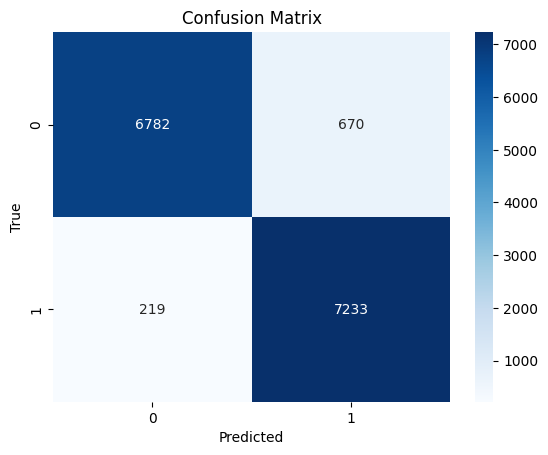

(0.19777958587379912, 0.9403515834675255)

In [22]:
evaluate_infer(model, val_loader, criterion, device, print_report=True)

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [24]:
def plot_binary_roc(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            outputs = model(X)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Get probability for class 1 (positive class)
            all_labels.append(y.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Binary ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

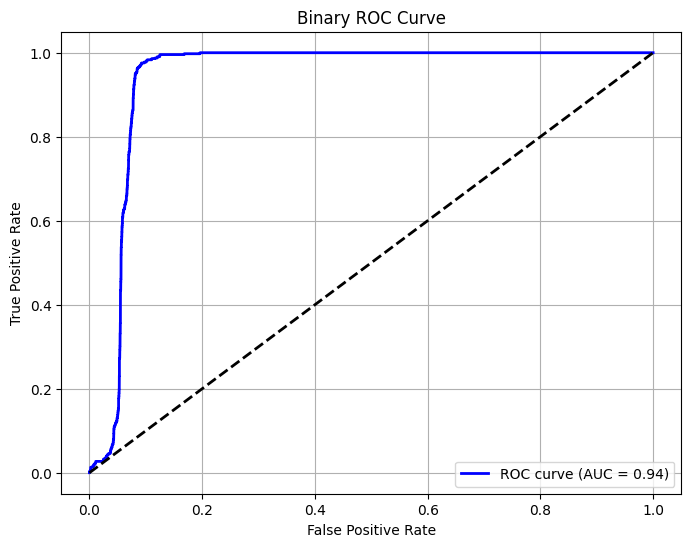

In [25]:
plot_binary_roc(model, val_loader, device)